In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

## 1. PINN Architecture Definition
Definition of the standard Neural Network to approximate the solution $u(t,x)$ containing the trainable parameter `alpha`.

In [2]:
class PinnHeatEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 50)
        self.couche_cachee1 = nn.Linear(50, 50)
        self.couche_cachee2 = nn.Linear(50, 50)
        self.couche_sortie = nn.Linear(50, 1)
        # Initialising alpha by 0.01 randomly
        self.alpha = nn.Parameter(torch.tensor([0.01], dtype=torch.float32))

    def forward(self, x):
        x = torch.tanh(self.couche_entree(x))
        x = torch.tanh(self.couche_cachee1(x))
        x = torch.tanh(self.couche_cachee2(x))
        return self.couche_sortie(x)

## 2. Sampling, Collocation, and Observation Points Generation
Functions to generate collocation points (in the domain), initial points ($t=0$), boundary points ($x=0$ and $x=1$), and synthetic observation data used for identifying $\alpha$.

In [3]:
t_min, t_max = 0.0, 1.0
x_min, x_max = 0.0, 1.0


def generer_points_collocation(n_pde):
    t_colloc = torch.rand(n_pde, 1) * (t_max - t_min) + t_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return t_colloc.float(), x_colloc.float()


def generer_points_initiaux(n_iv):
    t_init = torch.zeros(n_iv, 1)
    x_init = torch.rand(n_iv, 1) * (x_max - x_min) + x_min
    return t_init.float(), x_init.float()


def generer_points_bords(n_bords):
    t_bord = torch.rand(n_bords, 1) * (t_max - t_min) + t_min
    x_gauche = torch.ones(n_bords // 2, 1) * x_min
    x_droite = torch.ones(n_bords // 2, 1) * x_max
    x_bord = torch.cat([x_gauche, x_droite], dim=0)
    return t_bord.float(), x_bord.float()


# Synthetic observation data generation (with measurement noise)
t_data = torch.rand(400, 1)
x_data = torch.rand(400, 1) * (x_max - x_min) + x_min
inputs_data = torch.cat([t_data, x_data], dim=1)
alpha_vrai = 0.0005 
u_vrai = torch.exp(-alpha_vrai * 4 * (torch.pi**2) * t_data) * torch.sin(2 * torch.pi * x_data)
noise_level = 0.10  # Gaussian noise, 10% of the signal std
u_data = u_vrai + noise_level * u_vrai.std() * torch.randn_like(u_vrai)

## 3. Loss Functions Definition
Grouping of loss calculation functions for initial conditions (IV), boundary conditions (BC), PDE residual (CLP), and observation data.

In [4]:
def calc_iv_loss(model, t_init, x_init, u_exact_init):
    u_pred = model(torch.cat([t_init, x_init], dim=1))
    return torch.mean((u_pred - u_exact_init) ** 2)


def calc_bc_loss(model, t_bord, x_bord, u_exact_bord):
    u_pred = model(torch.cat([t_bord, x_bord], dim=1))
    return torch.mean((u_pred - u_exact_bord) ** 2)


def calc_clp_loss(model, t_colloc, x_colloc, alpha):
    t_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    u_pred = model(torch.cat([t_colloc, x_colloc], dim=1))

    u_t = torch.autograd.grad(
        outputs=u_pred,
        inputs=t_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_x = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]

    residu = u_t - alpha * u_xx
    return torch.mean(residu ** 2)


def calc_data_loss(model, inputs_data, u_data):
    u_pred_data = model(inputs_data)
    return torch.mean((u_pred_data - u_data) ** 2)

## 4. Hardware (Device), Model, and Data Initialization
Hardware detection, inverse model creation, definition of the Adam optimizer with two distinct learning rates (parameter group for `alpha`), and transfer of points to the device.

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

modele = PinnHeatEq().to(device)


optimizer = optim.Adam([
    {'params': [p for n, p in modele.named_parameters() if n != 'alpha'], 'lr': 0.001},
    {'params': [modele.alpha], 'lr': 0.02} # different lr to get a fast convergence
])

t_colloc, x_colloc = generer_points_collocation(12000)
t_init, x_init = generer_points_initiaux(1000)
t_bord, x_bord = generer_points_bords(1000)

u_exact_init = torch.sin(2 * torch.pi * x_init)
u_exact_bord = torch.zeros_like(x_bord)

t_colloc, x_colloc = t_colloc.to(device), x_colloc.to(device)
t_init, x_init = t_init.to(device), x_init.to(device)
t_bord, x_bord = t_bord.to(device), x_bord.to(device)
u_exact_init = u_exact_init.to(device)
u_exact_bord = u_exact_bord.to(device)

inputs_data = inputs_data.to(device)
u_data = u_data.to(device)

cuda


## 5. Model Training (Adam)
Training phase of the inverse problem with the Adam optimizer to identify the physical parameter $\alpha$.

In [6]:
epochs = 20000

print("--- INVERSE PROBLEM TRAINING WITH ADAM ---")
for epoch in range(epochs):
    optimizer.zero_grad()

    loss_iv = calc_iv_loss(modele, t_init, x_init, u_exact_init)
    loss_bc = calc_bc_loss(modele, t_bord, x_bord, u_exact_bord)
    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, modele.alpha)
    loss_data = calc_data_loss(modele, inputs_data, u_data)

    loss_totale = 300 * loss_iv + 100 * loss_bc + loss_clp + loss_data
    loss_totale.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:05d} | "
              f"Total loss: {loss_totale.item():.2e} | "
              f"CLP: {loss_clp.item():.2e} | "
              f"BC: {loss_bc.item():.2e} | "
              f"IV: {loss_iv.item():.2e} | "
              f"Alpha estimate: {modele.alpha.item():.2e}")

--- INVERSE PROBLEM TRAINING WITH ADAM ---
Epoch 00000 | Total loss: 1.63e+02 | CLP: 7.40e-05 | BC: 3.53e-02 | IV: 5.31e-01 | Alpha estimate: -1.00e-02


C:\Users\Chabc\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 00100 | Total loss: 8.13e+01 | CLP: 8.51e-02 | BC: 1.59e-01 | IV: 2.17e-01 | Alpha estimate: 4.81e-01
Epoch 00200 | Total loss: 1.58e+01 | CLP: 5.02e-01 | BC: 3.91e-02 | IV: 3.69e-02 | Alpha estimate: 4.42e-02
Epoch 00300 | Total loss: 6.81e-01 | CLP: 1.26e-01 | BC: 1.32e-03 | IV: 1.15e-03 | Alpha estimate: 1.77e-02
Epoch 00400 | Total loss: 2.22e-01 | CLP: 8.14e-02 | BC: 3.51e-04 | IV: 1.70e-04 | Alpha estimate: 1.65e-02
Epoch 00500 | Total loss: 1.52e-01 | CLP: 6.19e-02 | BC: 1.92e-04 | IV: 7.03e-05 | Alpha estimate: 1.64e-02
Epoch 00600 | Total loss: 1.18e-01 | CLP: 4.78e-02 | BC: 1.31e-04 | IV: 4.19e-05 | Alpha estimate: 1.49e-02
Epoch 00700 | Total loss: 2.24e-01 | CLP: 3.68e-02 | BC: 3.66e-04 | IV: 3.69e-04 | Alpha estimate: 1.48e-02
Epoch 00800 | Total loss: 7.65e-02 | CLP: 2.92e-02 | BC: 7.10e-05 | IV: 2.02e-05 | Alpha estimate: 1.37e-02
Epoch 00900 | Total loss: 6.25e-02 | CLP: 2.32e-02 | BC: 5.28e-05 | IV: 1.43e-05 | Alpha estimate: 1.25e-02
Epoch 01000 | Total loss: 5.

## 6. Visualizing the Results
Comparison of the solution learned by the PINN with the exact analytical solution of the heat equation.

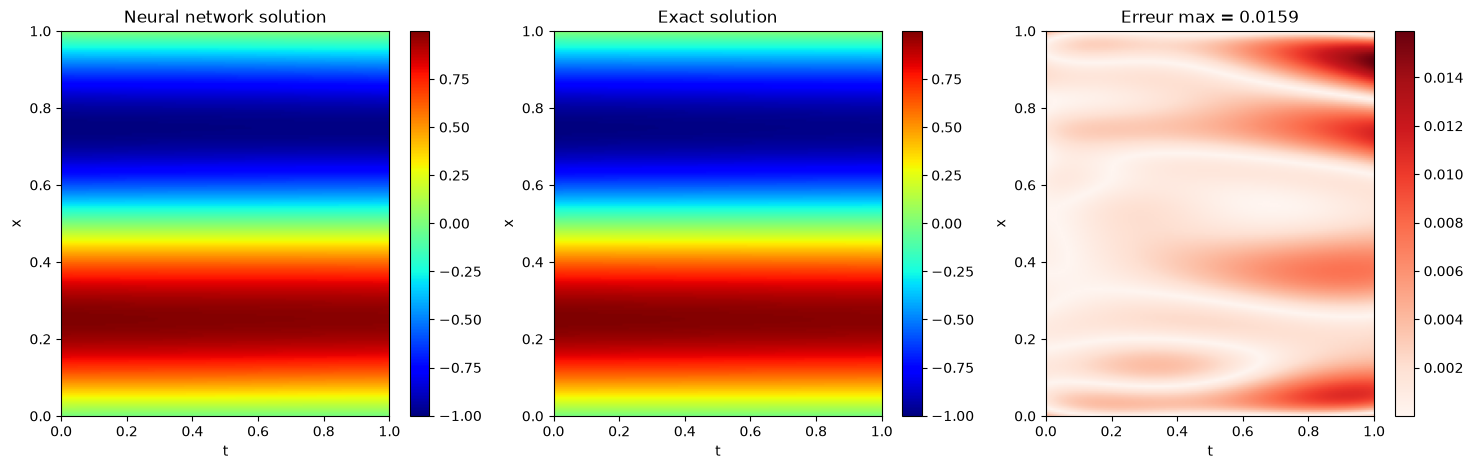

In [7]:
import sys; sys.path.append("..")
import numpy as np                                                                                                    
from pinnplot import plot_solution                        

u_exact = lambda t, x: np.sin(2*np.pi*x) * np.exp(-(2*np.pi)**2 * alpha_vrai * t)

plot_solution(modele, u_exact)

## Bonus Section: Alternative Comparison (Separate Adam + SGD)
Alternative comparison cell using separate Adam (Network) and SGD (Alpha) with gradient clipping to prevent NaN at startup.

In [8]:
# Clean re-instantiation
modele_sol2 = PinnHeatEq().to(device)

# Two separate optimizers
optimizer_net = optim.Adam([p for n, p in modele_sol2.named_parameters() if n != 'alpha'], lr=0.001)
optimizer_alpha = optim.SGD([modele_sol2.alpha], lr=0.005) # SGD with moderate lr for alpha

epochs = 2000
print("--- TRAINING SOLUTION 2 (Separate Adam + SGD) ---")
for epoch in range(epochs):
    optimizer_net.zero_grad()
    optimizer_alpha.zero_grad()
    
    loss_iv = calc_iv_loss(modele_sol2, t_init, x_init, u_exact_init)
    loss_bc = calc_bc_loss(modele_sol2, t_bord, x_bord, u_exact_bord)
    loss_clp = calc_clp_loss(modele_sol2, t_colloc, x_colloc, modele_sol2.alpha)
    loss_data = calc_data_loss(modele_sol2, inputs_data, u_data)
    
    loss_totale = 300 * loss_iv + 100 * loss_bc + loss_clp + loss_data
    loss_totale.backward()
    
    # Gradient clipping in case of diverging
    torch.nn.utils.clip_grad_value_([modele_sol2.alpha], clip_value=0.1)
    
    optimizer_net.step()
    optimizer_alpha.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:05d} | Total loss: {loss_totale.item():.2e} | CLP: {loss_clp.item():.2e} | Alpha estimate: {modele_sol2.alpha.item():.2e}")

--- TRAINING SOLUTION 2 (Separate Adam + SGD) ---
Epoch 00000 | Total loss: 1.60e+02 | CLP: 1.59e-03 | Alpha estimate: 1.00e-02
Epoch 00100 | Total loss: 7.65e+01 | CLP: 1.70e-01 | Alpha estimate: 6.19e-03
Epoch 00200 | Total loss: 2.47e+01 | CLP: 3.01e+00 | Alpha estimate: -5.11e-03
Epoch 00300 | Total loss: 2.82e+00 | CLP: 8.32e-01 | Alpha estimate: 4.49e-02
Epoch 00400 | Total loss: 5.09e-01 | CLP: 1.49e-01 | Alpha estimate: 6.41e-02
Epoch 00500 | Total loss: 3.15e-01 | CLP: 5.74e-02 | Alpha estimate: 5.45e-02
Epoch 00600 | Total loss: 2.16e-01 | CLP: 3.19e-02 | Alpha estimate: 4.57e-02
Epoch 00700 | Total loss: 1.73e-01 | CLP: 2.12e-02 | Alpha estimate: 3.93e-02
Epoch 00800 | Total loss: 1.53e-01 | CLP: 1.59e-02 | Alpha estimate: 3.41e-02
Epoch 00900 | Total loss: 1.23e-01 | CLP: 1.34e-02 | Alpha estimate: 2.95e-02
Epoch 01000 | Total loss: 1.07e-01 | CLP: 1.21e-02 | Alpha estimate: 2.61e-02
Epoch 01100 | Total loss: 1.10e-01 | CLP: 1.13e-02 | Alpha estimate: 2.32e-02
Epoch 01200 |